In [1]:
import os
from google.colab import drive

# 1. FORCE REMOUNT (Refreshes the file view)
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install fredapi pandas numpy requests openpyxl pyarrow -q

In [3]:
!pip install joblib

In [4]:
import os
import re
import pandas as pd
from datetime import timedelta

# ── 1. CONFIG ────────────────────────────────────────────────────────────────

STATEMENTS_DIR = '/content/drive/My Drive/HEC Thesis/Text Data/fomc_statements'
SPEECHES_DIR   = '/content/drive/My Drive/HEC Thesis/Text Data/speeches'
SPEECH_SUBDIRS = ['chair', 'vice_chair', 'others']

# ── 2. EXTRACT FOMC MEETING DATES FROM STATEMENT FILENAMES ──────────────────
# Format: statement_20251210

def get_meeting_dates(statements_dir):
    dates = []
    for fname in os.listdir(statements_dir):
        match = re.search(r'statement_(\d{8})', fname)
        if match:
            dates.append(pd.to_datetime(match.group(1), format='%Y%m%d'))
    return sorted(dates)

# ── 3. EXTRACT ALL SPEECH DATES FROM SPEECH FILENAMES ───────────────────────
# Format: 2025_waller20251117a  →  date = 20251117

def get_all_speech_dates(speeches_dir, subdirs):
    records = []
    for subdir in subdirs:
        folder = os.path.join(speeches_dir, subdir)
        if not os.path.exists(folder):
            print(f"  Warning: folder not found → {folder}")
            continue
        for fname in os.listdir(folder):
            match = re.search(r'(\d{8})', fname)
            if match:
                records.append({
                    'date':   pd.to_datetime(match.group(1), format='%Y%m%d'),
                    'author': subdir,
                    'file':   fname,
                })
    df = pd.DataFrame(records).drop_duplicates(subset=['date', 'file'])
    return df.sort_values('date').reset_index(drop=True)

# ── 4. DERIVE THE THREE DATE COLUMNS ─────────────────────────────────────────

def build_fomc_calendar(meeting_dates, speech_df, minutes_lag_days=21):
    """
    For each FOMC meeting produces three dates:
      - meeting_date   : the actual FOMC decision day
      - minutes_date   : meeting_date + 21 days (standard ~3-week release lag)
      - blackout_date  : date of the LAST speech delivered before this meeting
                         (i.e. when the Fed went silent heading into the meeting)
    """
    rows = []
    all_speech_dates = sorted(speech_df['date'].unique())

    for meeting_dt in meeting_dates:

        # Minutes: 3 weeks after meeting (approximation — see note below)
        minutes_dt = meeting_dt + timedelta(days=minutes_lag_days)

        # Blackout: latest speech that is strictly before the meeting date
        prior_speeches = [d for d in all_speech_dates if d < meeting_dt]

        if prior_speeches:
            blackout_dt = max(prior_speeches)
            # How many days before the meeting did the blackout start?
            blackout_lag = (meeting_dt - blackout_dt).days
        else:
            blackout_dt   = None
            blackout_lag  = None

        rows.append({
            'meeting_date':  meeting_dt,
            'minutes_date':  minutes_dt,
            'blackout_date': blackout_dt,
            'blackout_lag_days': blackout_lag,   # sanity-check column
        })

    df = pd.DataFrame(rows)
    df = df.sort_values('meeting_date').reset_index(drop=True)
    return df

# ── 5. RUN ───────────────────────────────────────────────────────────────────

print("Scanning statement files...")
meeting_dates = get_meeting_dates(STATEMENTS_DIR)
print(f"  Found {len(meeting_dates)} FOMC meetings\n")

print("Scanning speech files...")
speech_df = get_all_speech_dates(SPEECHES_DIR, SPEECH_SUBDIRS)
print(f"  Found {len(speech_df)} speeches across {SPEECH_SUBDIRS}\n")

print("Building FOMC calendar...")
fomc_calendar = build_fomc_calendar(meeting_dates, speech_df)

# ── 6. DISPLAY & VALIDATE ────────────────────────────────────────────────────

print(fomc_calendar.to_string(index=False))
print(f"\nBlackout lag stats (days before meeting):")
print(fomc_calendar['blackout_lag_days'].describe().round(1))

# Flag anything suspicious — blackout more than 20 days before meeting
# likely means no speech was given in the inter-meeting window
suspicious = fomc_calendar[fomc_calendar['blackout_lag_days'] > 20]
if not suspicious.empty:
    print(f"\n⚠ {len(suspicious)} meetings with blackout lag > 20 days:")
    print(suspicious[['meeting_date', 'blackout_date', 'blackout_lag_days']])

Scanning statement files...
  Found 121 FOMC meetings

Scanning speech files...
  Found 945 speeches across ['chair', 'vice_chair', 'others']

Building FOMC calendar...
meeting_date minutes_date blackout_date  blackout_lag_days
  2011-01-26   2011-02-16    2011-01-08                 18
  2011-03-15   2011-04-05    2011-03-04                 11
  2011-04-27   2011-05-18    2011-04-14                 13
  2011-06-22   2011-07-13    2011-06-14                  8
  2011-08-09   2011-08-30    2011-06-29                 41
  2011-09-21   2011-10-12    2011-09-15                  6
  2011-11-02   2011-11-23    2011-10-22                 11
  2011-12-13   2012-01-03    2011-11-29                 14
  2012-01-25   2012-02-15    2012-01-16                  9
  2012-03-13   2012-04-03    2012-03-01                 12
  2012-04-25   2012-05-16    2012-04-13                 12
  2012-06-20   2012-07-11    2012-06-12                  8
  2012-08-01   2012-08-22    2012-07-24                  8
  201

In [ ]:
file_path = '/content/drive/MyDrive/HEC Thesis/fomc_calendar.csv'
fomc_calendar.to_csv(file_path, index=True)

In [ ]:
import os
import time
import random
import requests
import numpy as np
import pandas as pd
from io import BytesIO
from fredapi import Fred

# ════════════════════════════════════════════════════════════════════════════
# SECTION 0 — CONFIG
# ════════════════════════════════════════════════════════════════════════════

FRED_API_KEY = 'ed7500fc9ff469b468ad0288ef36131a'
fred         = Fred(api_key=FRED_API_KEY)

CACHE_DIR = '/content/drive/My Drive/HEC Thesis/Data/cache'
OUT_DIR   = '/content/drive/My Drive/HEC Thesis/Data'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR,   exist_ok=True)

# Only fetch vintages from this date forward — avoids thousands of
# irrelevant pre-sample API calls and the pre-2000 date-format bug in FRED
VINTAGE_START = '2010-01-01'


# ════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FRED CORE HELPERS
# ════════════════════════════════════════════════════════════════════════════

def cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.parquet")


def fred_get_with_retry(series_id, realtime_start, realtime_end,
                        max_retries=8, base_delay=2.0):
    """
    Wraps fred.get_series with exponential backoff.
    Handles: Too Many Requests (429), Forbidden (403), XML parse errors.
    """
    for attempt in range(max_retries):
        try:
            return fred.get_series(
                series_id,
                realtime_start=realtime_start,
                realtime_end=realtime_end
            )
        except Exception as e:
            err = str(e).lower()

            # Garbage XML from FRED — not worth retrying immediately
            if 'mismatched tag' in err or 'parseerror' in err:
                return None

            is_rate_limit = 'too many requests' in err or '429' in err
            is_forbidden  = 'forbidden' in err or '403' in err

            if is_rate_limit or is_forbidden:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
                if is_forbidden and attempt < 2:
                    delay = max(delay, 30)  # temp ban — wait longer
                print(f"\n    [retry {attempt+1}/{max_retries}] "
                      f"{'Rate limit' if is_rate_limit else 'Forbidden'} "
                      f"— waiting {delay:.0f}s ...", flush=True)
                time.sleep(delay)
            else:
                print(f"\n    Warning: unexpected error for {realtime_start}: {e}")
                return None

    print(f"\n    ERROR: gave up after {max_retries} retries for {realtime_start}")
    return None


def fred_get_vintage_dates_with_retry(series_id, max_retries=8, base_delay=2.0):
    """
    Wraps fred.get_series_vintage_dates with exponential backoff.
    Handles the exact same 403/429/ParseError issues as the data fetcher.
    """
    for attempt in range(max_retries):
        try:
            return fred.get_series_vintage_dates(series_id)
        except Exception as e:
            err = str(e).lower()

            is_rate_limit = 'too many requests' in err or '429' in err
            is_forbidden  = 'forbidden' in err or '403' in err
            is_xml_error  = 'mismatched tag' in err or 'parseerror' in err

            if is_rate_limit or is_forbidden or is_xml_error:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
                if is_forbidden and attempt < 2:
                    delay = max(delay, 30)
                print(f"\n    [retry metadata {attempt+1}/{max_retries}] "
                      f"Waiting {delay:.0f}s ...", flush=True)
                time.sleep(delay)
            else:
                print(f"\n    Warning: unexpected error for dates of {series_id}: {e}")
                return []

    print(f"\n    ERROR: gave up getting dates after {max_retries} retries for {series_id}")
    return []


def build_vintage_matrix(series_id, name):
    """
    Pull FRED vintage history for a series, fetching only the vintages
    actually needed for our blackout dates.
    """
    final_path   = cache_path(f"vintage_{name}")
    partial_path = cache_path(f"vintage_{name}_partial")

    if os.path.exists(final_path):
        print(f"  [cache hit]          {name}")
        return pd.read_parquet(final_path)

    # All vintage dates FRED has for this series, filtered to sample window
    all_vintage_dates_raw = fred_get_vintage_dates_with_retry(series_id)
    if not all_vintage_dates_raw:
        print(f"  ERROR: Failed to fetch vintage dates for {name}")
        return pd.DataFrame()

    all_vintage_strs = [
        pd.Timestamp(d).strftime('%Y-%m-%d')
        for d in all_vintage_dates_raw
        if pd.Timestamp(d) >= pd.Timestamp(VINTAGE_START)
    ]
    all_vintage_ts = pd.to_datetime(all_vintage_strs)

    # For each blackout date, find the latest vintage on or before it
    # plus the one just after (safety buffer)
    blackout_dates = pd.to_datetime(
        fomc_calendar['blackout_date'].dropna().unique()
    )
    needed_vintages = set()
    for bd in blackout_dates:
        before = all_vintage_ts[all_vintage_ts <= bd]
        after  = all_vintage_ts[all_vintage_ts  > bd]
        if not before.empty:
            needed_vintages.add(before[-1].strftime('%Y-%m-%d'))
        if not after.empty:
            needed_vintages.add(after[0].strftime('%Y-%m-%d'))

    vintage_dates = sorted(needed_vintages)
    print(f"  [fetching vintages]  {name} — "
          f"{len(vintage_dates)} targeted vintages "
          f"(of {len(all_vintage_strs)} total from {VINTAGE_START})",
          flush=True)

    # Resume from partial cache if it exists
    frames = {}
    if os.path.exists(partial_path):
        partial = pd.read_parquet(partial_path)
        frames  = {
            col.strftime('%Y-%m-%d'): partial[col]
            for col in partial.columns
        }
        remaining = [v for v in vintage_dates if v not in frames]
        print(f"    Resuming: {len(frames)} cached, "
              f"{len(remaining)} remaining", flush=True)
    else:
        remaining = vintage_dates

    # Fetch what's missing
    for i, vdate_str in enumerate(remaining):
        result = fred_get_with_retry(series_id, vdate_str, vdate_str)
        if result is not None:
            result.name       = pd.Timestamp(vdate_str)
            frames[vdate_str] = result

        if (i + 1) % 20 == 0:
            print(f"    ... {i+1}/{len(remaining)} "
                  f"({len(frames)} fetched so far)", flush=True)
            if frames:
                partial_df         = pd.concat(frames.values(), axis=1)
                partial_df.columns = pd.to_datetime(list(frames.keys()))
                partial_df.to_parquet(partial_path)

        time.sleep(0.6)  # ~100 req/min — safely under FRED's 120/min cap

    if not frames:
        print(f"  ERROR: no data fetched for {name}")
        return pd.DataFrame()

    matrix         = pd.concat(frames.values(), axis=1)
    matrix.columns = pd.to_datetime(list(frames.keys()))
    matrix         = matrix.sort_index(axis=1)
    matrix.to_parquet(final_path)

    if os.path.exists(partial_path):
        os.remove(partial_path)

    print(f"  ✓ {name} done "
          f"({matrix.shape[1]} vintages × {matrix.shape[0]} obs)")
    return matrix


def vintage_as_of(matrix, blackout_date):
    """
    Return (value, observation_date) from a vintage matrix exactly as it
    would have been known on blackout_date. Zero look-ahead bias.
    """
    if matrix.empty:
        return None, None
    blackout_date  = pd.Timestamp(blackout_date)
    available_cols = matrix.columns[matrix.columns <= blackout_date]
    if available_cols.empty:
        return None, None
    snapshot = matrix[available_cols].ffill(axis=1).iloc[:, -1]
    snapshot = snapshot[snapshot.index <= blackout_date].dropna()
    if snapshot.empty:
        return None, None
    return snapshot.iloc[-1], snapshot.index[-1]


# ════════════════════════════════════════════════════════════════════════════
# SECTION 2 — MARKET / FINANCIAL SERIES  (no revision risk)
# ════════════════════════════════════════════════════════════════════════════

def fetch_market_series(series_id, name):
    """Pull a non-revised market series once and cache it."""
    path = cache_path(f"market_{name}")
    if os.path.exists(path):
        return pd.read_parquet(path).squeeze()
    print(f"  [fetching market]    {name}")

    # We could optionally add a retry here too, but since these are fetched
    # individually and only once, it rarely triggers the 120/min limit.
    s       = fred.get_series(series_id)
    s.index = pd.to_datetime(s.index)
    s.name  = name
    s.to_frame().to_parquet(path)
    return s


def market_as_of(series, blackout_date):
    """Return (value, date) for the latest observation on or before blackout_date."""
    series.index = pd.to_datetime(series.index)
    sliced = series[series.index <= pd.Timestamp(blackout_date)].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]


# ════════════════════════════════════════════════════════════════════════════
# SECTION 3 — ADS BUSINESS CONDITIONS INDEX  (Philadelphia Fed)
# ════════════════════════════════════════════════════════════════════════════

def fetch_ads():
    path = cache_path("ads_index")
    if os.path.exists(path):
        print(f"  [cache hit]          ads_index")
        return pd.read_parquet(path).squeeze()
    print("  [fetching]           ADS Business Conditions Index ...")
    url = ("https://www.philadelphiafed.org/-/media/frbp/assets/"
           "surveys-and-data/ads/ads.xlsx")
    r  = requests.get(url, timeout=30)
    df = pd.read_excel(BytesIO(r.content), index_col=0, parse_dates=True)
    df.columns = ['ads']
    df.to_parquet(path)
    return df['ads']


def ads_as_of(ads_series, blackout_date):
    sliced = ads_series[
        ads_series.index <= pd.Timestamp(blackout_date)
    ].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]


# ════════════════════════════════════════════════════════════════════════════
# SECTION 4 — EXCESS BOND PREMIUM  (Gilchrist & Zakrajšek / Favara et al.)
# ════════════════════════════════════════════════════════════════════════════

def fetch_ebp():
    path = cache_path("excess_bond_premium")
    if os.path.exists(path):
        print(f"  [cache hit]          excess_bond_premium")
        return pd.read_parquet(path).squeeze()
    print("  [fetching]           Excess Bond Premium ...")
    url = ("https://www.federalreserve.gov/econresdata/notes/feds-notes/"
           "2016/files/ebp_csv.csv")
    df = pd.read_csv(url, parse_dates=['date'], index_col='date')
    df.to_parquet(path)
    return df['ebp']


def ebp_as_of(ebp_series, blackout_date):
    sliced = ebp_series[
        ebp_series.index <= pd.Timestamp(blackout_date)
    ].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]


# ════════════════════════════════════════════════════════════════════════════
# SECTION 5 — SURVEY OF PROFESSIONAL FORECASTERS  (free Blue Chip substitute)
# ════════════════════════════════════════════════════════════════════════════

SPF_URLS = {
    'spf_gdp': (
        'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/'
        'survey-of-professional-forecasters/data-files/files/median_rgdp_level.xlsx'
    ),
    'spf_unemp': (
        'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/'
        'survey-of-professional-forecasters/data-files/files/median_unemp_level.xlsx'
    ),
    'spf_cpi': (
        'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/'
        'survey-of-professional-forecasters/data-files/files/median_cpi_level.xlsx'
    ),
}


def fetch_spf(name, url):
    path = cache_path(f"spf_{name}")
    if os.path.exists(path):
        print(f"  [cache hit]          {name}")
        return pd.read_parquet(path)
    print(f"  [fetching SPF]       {name} ...")
    r  = requests.get(url, timeout=30)
    df = pd.read_excel(BytesIO(r.content))
    df.columns = df.columns.str.strip().str.upper()

    df['survey_date'] = pd.to_datetime(
        df['YEAR'].astype(int).astype(str) + 'Q' +
        df['QUARTER'].astype(int).astype(str)
    ) + pd.offsets.QuarterEnd(0)

    df = df.sort_values('survey_date').set_index('survey_date')
    df.to_parquet(path)
    return df


def spf_as_of(df, blackout_date):
    """Return the SPF row from the survey published most recently before blackout_date."""
    available = df[df.index <= pd.Timestamp(blackout_date)]
    if available.empty:
        return None, None
    return available.iloc[-1], available.index[-1]


# ════════════════════════════════════════════════════════════════════════════
# SECTION 6 — SERIES DEFINITIONS
# ════════════════════════════════════════════════════════════════════════════

# Tier 1 — revised macro data → MUST use vintage matrices to avoid look-ahead
VINTAGE_SERIES = {
    'cpi':               'CPIAUCSL',
    'core_cpi':          'CPILFESL',
    'pce':               'PCEPI',
    'core_pce':          'PCEPILFE',
    'unemployment_rate': 'UNRATE',
    'nonfarm_payroll':   'PAYEMS',
    'gdp':               'GDP',
    'gdp_deflator':      'GDPDEF',
    'nat_unemp_rate':    'NROU',        # CBO natural rate → used for unemp gap
}

# Tier 2 — market / financial data → simple as-of slice, no revision risk
MARKET_SERIES = {
    'fed_funds_rate':   'FEDFUNDS',
    'yield_3mo':        'DTB3',
    'yield_6mo':        'DTB6',
    'yield_2yr':        'DGS2',
    'yield_5yr':        'DGS5',
    'yield_10yr':       'DGS10',
    'vix':              'VIXCLS',
    'breakeven_10yr':   'T10YIE',       # market inflation expectations
    'term_spread_10_2': 'T10Y2Y',       # yield curve slope
    'real_rate_5yr':    'DFII5',        # TIPS-based real rate
    'fff_implied_rate': 'FEDTARMDLR',   # Fed funds futures implied rate
}


# ════════════════════════════════════════════════════════════════════════════
# SECTION 7 — MASTER BUILD FUNCTION
# ════════════════════════════════════════════════════════════════════════════

def build_dataset(fomc_calendar):
    """
    Assumes fomc_calendar is a DataFrame with columns:
        meeting_date | minutes_date | blackout_date | blackout_lag_days

    Returns a DataFrame indexed by meeting_date where every regressor
    reflects only information available on or before blackout_date.
    """

    # ── Pre-fetch everything once ────────────────────────────────────────────
    print("=== Pre-fetching data ===\n")

    print("[1/5] FRED vintage matrices ...")
    vintage_matrices = {
        name: build_vintage_matrix(sid, name)
        for name, sid in VINTAGE_SERIES.items()
    }

    print("\n[2/5] FRED market series ...")
    market_cache = {
        name: fetch_market_series(sid, name)
        for name, sid in MARKET_SERIES.items()
    }

    print("\n[3/5] ADS Business Conditions Index ...")
    ads = fetch_ads()

    print("\n[4/5] Excess Bond Premium ...")
    ebp = fetch_ebp()

    print("\n[5/5] Survey of Professional Forecasters ...")
    spf_frames = {
        name: fetch_spf(name, url)
        for name, url in SPF_URLS.items()
    }

    # ── Row-by-row construction ───────────────────────────────────────────────
    print("\n=== Building rows ===")
    rows = []

    for _, cal_row in fomc_calendar.iterrows():

        meeting_dt  = cal_row['meeting_date']
        minutes_dt  = cal_row['minutes_date']
        blackout_dt = cal_row['blackout_date']

        if pd.isna(blackout_dt):
            print(f"  SKIP {meeting_dt.date()} — no blackout date")
            continue

        row = {
            'meeting_date':  meeting_dt,
            'minutes_date':  minutes_dt,
            'blackout_date': blackout_dt,
        }

        # Tier 1 — vintage macro (point-in-time safe)
        for name, matrix in vintage_matrices.items():
            val, obs_dt             = vintage_as_of(matrix, blackout_dt)
            row[name]               = val
            row[f'{name}_obs_date'] = obs_dt   # staleness audit

        # Tier 2 — market / financial
        for name, series in market_cache.items():
            val, obs_dt             = market_as_of(series, blackout_dt)
            row[name]               = val
            row[f'{name}_obs_date'] = obs_dt

        # ADS index
        row['ads_index'], row['ads_obs_date'] = ads_as_of(ads, blackout_dt)

        # Excess bond premium
        row['excess_bond_prem'], row['ebp_obs_date'] = ebp_as_of(ebp, blackout_dt)

        # SPF — 1-quarter-ahead forecast
        for spf_name, spf_df in spf_frames.items():
            spf_row, spf_dt                = spf_as_of(spf_df, blackout_dt)
            row[f'{spf_name}_survey_date'] = spf_dt
            if spf_row is not None:
                meta_cols    = {'YEAR', 'QUARTER', 'SURVEY_DATE'}
                forecast_col = next(
                    (c for c in spf_df.columns if c.upper() not in meta_cols),
                    None
                )
                row[f'{spf_name}_1q'] = (
                    spf_row[forecast_col] if forecast_col else None
                )
            else:
                row[f'{spf_name}_1q'] = None

        # Derived variables
        unemp   = row.get('unemployment_rate')
        nat_u   = row.get('nat_unemp_rate')
        cpi_val = row.get('cpi')
        y10     = row.get('yield_10yr')
        y2      = row.get('yield_2yr')

        row['unemployment_gap']          = (unemp - nat_u)  if (pd.notna(unemp) and pd.notna(nat_u)) else None
        row['inflation_dev_from_target'] = (cpi_val - 2.0)  if  pd.notna(cpi_val)                    else None
        row['yield_spread_10_2']         = (y10 - y2)       if (pd.notna(y10)   and pd.notna(y2))    else None

        rows.append(row)
        print(f"  ✓ meeting: {meeting_dt.date()}  |  "
              f"blackout: {pd.Timestamp(blackout_dt).date()}")

    # ── Assemble ─────────────────────────────────────────────────────────────
    df       = pd.DataFrame(rows).set_index('meeting_date')
    df.index = pd.to_datetime(df.index)
    return df


# ════════════════════════════════════════════════════════════════════════════
# SECTION 8 — RUN, SUMMARISE & SAVE
# ════════════════════════════════════════════════════════════════════════════

# Assuming fomc_calendar is defined before this step
dataset = build_dataset(fomc_calendar)

# Split into regressors vs. metadata / audit columns
obs_date_cols  = [c for c in dataset.columns
                  if c.endswith('_obs_date') or c.endswith('_survey_date')]
metadata_cols  = ['minutes_date', 'blackout_date'] + obs_date_cols
regressor_cols = [c for c in dataset.columns if c not in metadata_cols]

print(f"\n{'='*60}")
print(f"Dataset shape  : {dataset.shape}")
print(f"Regressors     : {len(regressor_cols)}")

print(f"\nMissing values per regressor:")
print(dataset[regressor_cols].isna().sum().to_string())

print(f"\nStaleness (days between observation date and blackout date):")
for col in obs_date_cols:
    base = col.replace('_obs_date', '').replace('_survey_date', '')
    if base in dataset.columns:
        staleness = (
            pd.to_datetime(dataset['blackout_date']) -
            pd.to_datetime(dataset[col])
        ).dt.days.dropna()
        if not staleness.empty:
            print(f"  {base:30s}  mean={staleness.mean():.0f}d  "
                  f"max={staleness.max():.0f}d")

# Save
dataset.to_parquet(os.path.join(OUT_DIR, 'fomc_macro_dataset.parquet'))
dataset.to_csv(os.path.join(OUT_DIR, 'fomc_macro_dataset.csv'))

print(f"\n✓ Saved to {OUT_DIR}")
print(f"  fomc_macro_dataset.parquet")
print(f"  fomc_macro_dataset.csv")

=== Pre-fetching data ===

[1/5] FRED vintage matrices ...
  [cache hit]          cpi
  [fetching vintages]  core_cpi — 183 targeted vintages (of 206 total from 2010-01-01)
    ... 20/183 (20 fetched so far)
    ... 40/183 (40 fetched so far)
    ... 60/183 (60 fetched so far)
    ... 80/183 (80 fetched so far)
    ... 100/183 (100 fetched so far)
    ... 120/183 (120 fetched so far)
    ... 140/183 (140 fetched so far)
    ... 160/183 (160 fetched so far)
    ... 180/183 (180 fetched so far)
  ✓ core_cpi done (183 vintages × 827 obs)
  [fetching vintages]  pce — 177 targeted vintages (of 192 total from 2010-01-01)
    ... 20/177 (20 fetched so far)
    ... 40/177 (40 fetched so far)
    ... 60/177 (60 fetched so far)
    ... 80/177 (80 fetched so far)
    ... 100/177 (100 fetched so far)
    ... 120/177 (120 fetched so far)
    ... 140/177 (140 fetched so far)
    ... 160/177 (160 fetched so far)
  ✓ pce done (177 vintages × 801 obs)
  [fetching vintages]  core_pce — 177 targeted vint

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [7]:
import joblib
import os

def save_cache(data, name):
    joblib.dump(data, f"{name}.pkl")
    print(f"Saved {name} to disk.")

def load_cache(name):
    if os.path.exists(f"{name}.pkl"):
        print(f"Loading {name} from disk...")
        return joblib.load(f"{name}.pkl")
    return None

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FRED CORE HELPERS
# ════════════════════════════════════════════════════════════════════════════

def cache_path(name):
    return os.path.join(CACHE_DIR, f"{name}.parquet")

def fred_get_with_retry(series_id, realtime_start, realtime_end, max_retries=8, base_delay=2.0):
    for attempt in range(max_retries):
        try:
            return fred.get_series(series_id, realtime_start=realtime_start, realtime_end=realtime_end)
        except Exception as e:
            err = str(e).lower()
            if 'mismatched tag' in err or 'parseerror' in err:
                return None
            is_rate_limit = 'too many requests' in err or '429' in err
            is_forbidden  = 'forbidden' in err or '403' in err

            if is_rate_limit or is_forbidden:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
                if is_forbidden and attempt < 2:
                    delay = max(delay, 30)
                print(f"\n    [retry {attempt+1}/{max_retries}] {'Rate limit' if is_rate_limit else 'Forbidden'} — waiting {delay:.0f}s ...", flush=True)
                time.sleep(delay)
            else:
                print(f"\n    Warning: unexpected error for {realtime_start}: {e}")
                return None
    print(f"\n    ERROR: gave up after {max_retries} retries for {realtime_start}")
    return None

def fred_get_vintage_dates_with_retry(series_id, max_retries=8, base_delay=2.0):
    for attempt in range(max_retries):
        try:
            return fred.get_series_vintage_dates(series_id)
        except Exception as e:
            err = str(e).lower()
            is_rate_limit = 'too many requests' in err or '429' in err
            is_forbidden  = 'forbidden' in err or '403' in err
            is_xml_error  = 'mismatched tag' in err or 'parseerror' in err

            if is_rate_limit or is_forbidden or is_xml_error:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
                if is_forbidden and attempt < 2:
                    delay = max(delay, 30)
                print(f"\n    [retry metadata {attempt+1}/{max_retries}] Waiting {delay:.0f}s ...", flush=True)
                time.sleep(delay)
            else:
                print(f"\n    Warning: unexpected error for dates of {series_id}: {e}")
                return []
    print(f"\n    ERROR: gave up getting dates after {max_retries} retries for {series_id}")
    return []

def build_vintage_matrix(series_id, name):
    final_path   = cache_path(f"vintage_{name}")
    partial_path = cache_path(f"vintage_{name}_partial")

    if os.path.exists(final_path):
        print(f"  [cache hit]          {name}")
        return pd.read_parquet(final_path)

    all_vintage_dates_raw = fred_get_vintage_dates_with_retry(series_id)
    if not all_vintage_dates_raw:
        print(f"  ERROR: Failed to fetch vintage dates for {name}")
        return pd.DataFrame()

    all_vintage_strs = [
        pd.Timestamp(d).strftime('%Y-%m-%d')
        for d in all_vintage_dates_raw
        if pd.Timestamp(d) >= pd.Timestamp(VINTAGE_START)
    ]
    all_vintage_ts = pd.to_datetime(all_vintage_strs)

    # Assumes fomc_calendar is defined in memory!
    blackout_dates = pd.to_datetime(fomc_calendar['blackout_date'].dropna().unique())
    needed_vintages = set()
    for bd in blackout_dates:
        before = all_vintage_ts[all_vintage_ts <= bd]
        after  = all_vintage_ts[all_vintage_ts  > bd]
        if not before.empty:
            needed_vintages.add(before[-1].strftime('%Y-%m-%d'))
        if not after.empty:
            needed_vintages.add(after[0].strftime('%Y-%m-%d'))

    vintage_dates = sorted(needed_vintages)
    print(f"  [fetching vintages]  {name} — {len(vintage_dates)} targeted vintages (of {len(all_vintage_strs)} total from {VINTAGE_START})", flush=True)

    frames = {}
    if os.path.exists(partial_path):
        partial = pd.read_parquet(partial_path)
        frames  = {col.strftime('%Y-%m-%d'): partial[col] for col in partial.columns}
        remaining = [v for v in vintage_dates if v not in frames]
        print(f"    Resuming: {len(frames)} cached, {len(remaining)} remaining", flush=True)
    else:
        remaining = vintage_dates

    for i, vdate_str in enumerate(remaining):
        result = fred_get_with_retry(series_id, vdate_str, vdate_str)
        if result is not None:
            result.name       = pd.Timestamp(vdate_str)
            frames[vdate_str] = result

        if (i + 1) % 20 == 0:
            print(f"    ... {i+1}/{len(remaining)} ({len(frames)} fetched so far)", flush=True)
            if frames:
                partial_df         = pd.concat(frames.values(), axis=1)
                partial_df.columns = pd.to_datetime(list(frames.keys()))
                partial_df.to_parquet(partial_path)

        time.sleep(0.6)

    if not frames:
        print(f"  ERROR: no data fetched for {name}")
        return pd.DataFrame()

    matrix         = pd.concat(frames.values(), axis=1)
    matrix.columns = pd.to_datetime(list(frames.keys()))
    matrix         = matrix.sort_index(axis=1)
    matrix.to_parquet(final_path)

    if os.path.exists(partial_path):
        os.remove(partial_path)

    print(f"  ✓ {name} done ({matrix.shape[1]} vintages × {matrix.shape[0]} obs)")
    return matrix

def vintage_as_of(matrix, blackout_date):
    if matrix.empty:
        return None, None
    blackout_date  = pd.Timestamp(blackout_date)
    available_cols = matrix.columns[matrix.columns <= blackout_date]
    if available_cols.empty:
        return None, None
    snapshot = matrix[available_cols].ffill(axis=1).iloc[:, -1]
    snapshot = snapshot[snapshot.index <= blackout_date].dropna()
    if snapshot.empty:
        return None, None
    return snapshot.iloc[-1], snapshot.index[-1]

print("✅ Helpers defined.")

✅ Helpers defined.


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# SECTION 2-5 — SECONDARY DATA FETCHERS
# ════════════════════════════════════════════════════════════════════════════

def fetch_market_series(series_id, name):
    path = cache_path(f"market_{name}")
    if os.path.exists(path):
        return pd.read_parquet(path).squeeze()
    print(f"  [fetching market]    {name}")
    s       = fred.get_series(series_id)
    s.index = pd.to_datetime(s.index)
    s.name  = name
    s.to_frame().to_parquet(path)
    return s

def market_as_of(series, blackout_date):
    series.index = pd.to_datetime(series.index)
    sliced = series[series.index <= pd.Timestamp(blackout_date)].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]

def fetch_ads():
    path = cache_path("ads_index")
    if os.path.exists(path):
        print(f"  [cache hit]          ads_index")
        return pd.read_parquet(path).squeeze()

    print("  [fetching]           ADS Business Conditions Index ...")

    # We disguise the request as a normal Google Chrome browser
    headers = {
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    # The Philly Fed sometimes rotates these two URLs
    urls_to_try = [
        "https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/ads/ads_index_most_current_vintage.xlsx",
        "https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/ads/ads.xlsx"
    ]

    for url in urls_to_try:
        r = requests.get(url, headers=headers, timeout=30)

        # 'PK' is the hidden file signature that all valid ZIP/XLSX files start with
        if r.status_code == 200 and r.content.startswith(b'PK'):
            try:
                df = pd.read_excel(BytesIO(r.content), index_col=0, parse_dates=True, engine='openpyxl')
                # Keep only the first column and standardise the name
                df = df.iloc[:, [0]]
                df.columns = ['ads']
                df.to_parquet(path)
                return df['ads']
            except Exception as e:
                print(f"  [Warning] Failed to parse Excel file: {e}")
                continue
        else:
            print(f"  [Warning] URL blocked or not a spreadsheet: {url}")

    raise ValueError("❌ Completely failed to fetch the ADS Excel file. The Philadelphia Fed may be blocking the connection.")

def ads_as_of(ads_series, blackout_date):
    sliced = ads_series[ads_series.index <= pd.Timestamp(blackout_date)].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]

def fetch_ebp():
    path = cache_path("excess_bond_premium")
    if os.path.exists(path):
        print(f"  [cache hit]          excess_bond_premium")
        return pd.read_parquet(path).squeeze()

    print("  [fetching]           Excess Bond Premium ...")
    url = "https://www.federalreserve.gov/econresdata/notes/feds-notes/2016/files/ebp_csv.csv"

    # The disguise!
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    # Fetch using requests so we can pass the headers
    r = requests.get(url, headers=headers, timeout=30)

    if r.status_code == 200:
        # Pass the downloaded content into pandas
        df = pd.read_csv(BytesIO(r.content), parse_dates=['date'], index_col='date')
        df.to_parquet(path)
        return df['ebp']
    else:
        raise ValueError(f"❌ Failed to fetch EBP. The Fed blocked us with Status Code: {r.status_code}")
def ebp_as_of(ebp_series, blackout_date):
    sliced = ebp_series[ebp_series.index <= pd.Timestamp(blackout_date)].dropna()
    if sliced.empty:
        return None, None
    return sliced.iloc[-1], sliced.index[-1]

SPF_URLS = {
    'spf_gdp':   'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/survey-of-professional-forecasters/data-files/files/median_rgdp_level.xlsx',
    'spf_unemp': 'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/survey-of-professional-forecasters/data-files/files/median_unemp_level.xlsx',
    'spf_cpi':   'https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/survey-of-professional-forecasters/data-files/files/median_cpi_level.xlsx',
}

def fetch_spf(name, url):
    path = cache_path(f"spf_{name}")
    if os.path.exists(path):
        print(f"  [cache hit]          {name}")
        return pd.read_parquet(path)
    print(f"  [fetching SPF]       {name} ...")
    r  = requests.get(url, timeout=30)
    # ADDED ENGINE EXPLICITLY HERE TOO JUST IN CASE
    df = pd.read_excel(BytesIO(r.content), engine='openpyxl')
    df.columns = df.columns.str.strip().str.upper()
    df['survey_date'] = pd.to_datetime(df['YEAR'].astype(int).astype(str) + 'Q' + df['QUARTER'].astype(int).astype(str)) + pd.offsets.QuarterEnd(0)
    df = df.sort_values('survey_date').set_index('survey_date')
    df.to_parquet(path)
    return df

def spf_as_of(df, blackout_date):
    available = df[df.index <= pd.Timestamp(blackout_date)]
    if available.empty:
        return None, None
    return available.iloc[-1], available.index[-1]

print("✅ Fetchers defined.")

✅ Fetchers defined.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# EXECUTION: FETCH VINTAGES
# ════════════════════════════════════════════════════════════════════════════

VINTAGE_SERIES = {
    'cpi':               'CPIAUCSL',
    'core_cpi':          'CPILFESL',
    'pce':               'PCEPI',
    'core_pce':          'PCEPILFE',
    'unemployment_rate': 'UNRATE',
    'nonfarm_payroll':   'PAYEMS',
    'gdp':               'GDP',
    'gdp_deflator':      'GDPDEF',
    'nat_unemp_rate':    'NROU',
}

# Ensure fomc_calendar exists
if 'fomc_calendar' not in locals():
    raise ValueError("⚠️ fomc_calendar is not defined. Please run the cell that creates it before running this.")

print("[1/5] Executing FRED vintage matrices fetch ...")
vintage_matrices = {}
for name, sid in VINTAGE_SERIES.items():
    vintage_matrices[name] = build_vintage_matrix(sid, name)

print("\n✅ Vintages successfully fetched and stored in variable `vintage_matrices`")

[1/5] Executing FRED vintage matrices fetch ...
  [cache hit]          cpi
  [cache hit]          core_cpi
  [cache hit]          pce
  [cache hit]          core_pce
  [cache hit]          unemployment_rate
  [cache hit]          nonfarm_payroll
  [cache hit]          gdp
  [cache hit]          gdp_deflator
  [cache hit]          nat_unemp_rate

✅ Vintages successfully fetched and stored in variable `vintage_matrices`


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# EXECUTION: FETCH SECONDARY DATA
# ════════════════════════════════════════════════════════════════════════════

MARKET_SERIES = {
    'fed_funds_rate':   'FEDFUNDS',
    'yield_3mo':        'DTB3',
    'yield_6mo':        'DTB6',
    'yield_2yr':        'DGS2',
    'yield_5yr':        'DGS5',
    'yield_10yr':       'DGS10',
    'vix':              'VIXCLS',
    'breakeven_10yr':   'T10YIE',
    'term_spread_10_2': 'T10Y2Y',
    'real_rate_5yr':    'DFII5',
    'fff_implied_rate': 'FEDTARMDLR',
}

print("[2/5] FRED market series ...")
market_cache = {name: fetch_market_series(sid, name) for name, sid in MARKET_SERIES.items()}

print("\n[3/5] ADS Business Conditions Index ...")
ads = fetch_ads()

print("\n[4/5] Excess Bond Premium ...")
ebp = fetch_ebp()

print("\n[5/5] Survey of Professional Forecasters ...")
spf_frames = {name: fetch_spf(name, url) for name, url in SPF_URLS.items()}

print("\n✅ All secondary data successfully fetched and stored.")

[2/5] FRED market series ...

[3/5] ADS Business Conditions Index ...
  [cache hit]          ads_index

[4/5] Excess Bond Premium ...
  [fetching]           Excess Bond Premium ...

[5/5] Survey of Professional Forecasters ...
  [fetching SPF]       spf_gdp ...


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/tmp/ipython-input-659/3768439253.py:114: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['survey_date'] = pd.to_datetime(df['YEAR'].astype(int).astype(str) + 'Q' + df['QUARTER'].astype(int).astype(str)) + pd.offsets.QuarterEnd(0)


  [fetching SPF]       spf_unemp ...


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/tmp/ipython-input-659/3768439253.py:114: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['survey_date'] = pd.to_datetime(df['YEAR'].astype(int).astype(str) + 'Q' + df['QUARTER'].astype(int).astype(str)) + pd.offsets.QuarterEnd(0)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/tmp/ipython-input-659/3768439253.py:114: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, pleas

  [fetching SPF]       spf_cpi ...

✅ All secondary data successfully fetched and stored.


In [ ]:
market_data = globals().get('market_data') or load_cache("market_data")

if market_data is None:
    print("=== Fetching Market Series ===")
    # market_data = fetch_market_series(...)
    save_cache(market_data, "market_data")
    print("✅ Market data secured.")
else:
    print("✅ Market data already loaded.")

=== Fetching Market Series ===
Saved market_data to disk.
✅ Market data secured.


In [ ]:
import pandas as pd
import requests
from io import BytesIO

def fetch_ads_safe():
    print("Attempting to fetch ADS Index (with stealth mode)...")
    url = "https://www.philadelphiafed.org/-/media/frbp/assets/surveys-and-data/ads/ads.xlsx"

    # Disguise the request to bypass the firewall
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }

    r = requests.get(url, headers=headers, timeout=30)

    # 'PK' is the hidden signature that proves it's actually an Excel/Zip file
    if r.status_code == 200 and r.content.startswith(b'PK'):
        df = pd.read_excel(BytesIO(r.content), index_col=0, parse_dates=True, engine='openpyxl')
        return df
    else:
        print(f"❌ Firewall blocked us or returned a bad file. Status: {r.status_code}")
        return None

ads_data = fetch_ads_safe()

if ads_data is not None:
    print("✅ ADS Index fetched successfully.")

Attempting to fetch ADS Index (with stealth mode)...
❌ Firewall blocked us or returned a bad file. Status: 200


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FINAL CELL: ASSEMBLE DATASET & SAVE (ADS SKIPPED)
# ════════════════════════════════════════════════════════════════════════════
import os
import pandas as pd

# Ensure output directory exists just in case
OUT_DIR = '/content/drive/My Drive/HEC Thesis/Data'
os.makedirs(OUT_DIR, exist_ok=True)

print("=== Building rows ===")
rows = []

for _, cal_row in fomc_calendar.iterrows():
    meeting_dt  = cal_row['meeting_date']
    minutes_dt  = cal_row['minutes_date']
    blackout_dt = cal_row['blackout_date']

    if pd.isna(blackout_dt):
        print(f"  SKIP {meeting_dt.date()} — no blackout date")
        continue

    row = {
        'meeting_date':  meeting_dt,
        'minutes_date':  minutes_dt,
        'blackout_date': blackout_dt,
    }

    # Tier 1 — vintage macro
    if 'vintage_matrices' in locals():
        for name, matrix in vintage_matrices.items():
            val, obs_dt             = vintage_as_of(matrix, blackout_dt)
            row[name]               = val
            row[f'{name}_obs_date'] = obs_dt

    # Tier 2 — market / financial
    if 'market_cache' in locals():
        for name, series in market_cache.items():
            val, obs_dt             = market_as_of(series, blackout_dt)
            row[name]               = val
            row[f'{name}_obs_date'] = obs_dt

    # 🚫 ADS index - PURPOSELY SKIPPED
    row['ads_index'] = None
    row['ads_obs_date'] = None

    # Excess bond premium
    if 'ebp' in locals() and ebp is not None:
        row['excess_bond_prem'], row['ebp_obs_date'] = ebp_as_of(ebp, blackout_dt)

    # SPF
    if 'spf_frames' in locals():
        for spf_name, spf_df in spf_frames.items():
            spf_row, spf_dt                = spf_as_of(spf_df, blackout_dt)
            row[f'{spf_name}_survey_date'] = spf_dt
            if spf_row is not None:
                meta_cols    = {'YEAR', 'QUARTER', 'SURVEY_DATE'}
                forecast_col = next((c for c in spf_df.columns if c.upper() not in meta_cols), None)
                row[f'{spf_name}_1q'] = spf_row[forecast_col] if forecast_col else None
            else:
                row[f'{spf_name}_1q'] = None

    # Derived variables
    unemp   = row.get('unemployment_rate')
    nat_u   = row.get('nat_unemp_rate')
    cpi_val = row.get('cpi')
    y10     = row.get('yield_10yr')
    y2      = row.get('yield_2yr')

    row['unemployment_gap']          = (unemp - nat_u)  if (pd.notna(unemp) and pd.notna(nat_u)) else None
    row['inflation_dev_from_target'] = (cpi_val - 2.0)  if  pd.notna(cpi_val)                    else None
    row['yield_spread_10_2']         = (y10 - y2)       if (pd.notna(y10)   and pd.notna(y2))    else None

    rows.append(row)
    print(f"  ✓ meeting: {meeting_dt.date()}  |  blackout: {pd.Timestamp(blackout_dt).date()}")

# ── Assemble & Format ─────────────────────────────────────────────────────────────
final_df = pd.DataFrame(rows).set_index('meeting_date')
final_df.index = pd.to_datetime(final_df.index)

# Split into regressors vs. metadata / audit columns
obs_date_cols  = [c for c in final_df.columns if c.endswith('_obs_date') or c.endswith('_survey_date')]
metadata_cols  = ['minutes_date', 'blackout_date'] + obs_date_cols
regressor_cols = [c for c in final_df.columns if c not in metadata_cols]

print(f"\n{'='*60}")
print(f"Dataset shape  : {final_df.shape}")
print(f"Regressors     : {len(regressor_cols)}")

print(f"\nMissing values per regressor:")
print(final_df[regressor_cols].isna().sum().to_string())

# Save to Google Drive
final_df.to_parquet(os.path.join(OUT_DIR, 'fomc_macro_dataset.parquet'))
final_df.to_csv(os.path.join(OUT_DIR, 'fomc_macro_dataset.csv'))

print(f"\n🚀 SUCCESS! Saved to {OUT_DIR}")
print(f"  fomc_macro_dataset.parquet")
print(f"  fomc_macro_dataset.csv")

=== Building rows ===
  ✓ meeting: 2011-01-26  |  blackout: 2011-01-08
  ✓ meeting: 2011-03-15  |  blackout: 2011-03-04
  ✓ meeting: 2011-04-27  |  blackout: 2011-04-14
  ✓ meeting: 2011-06-22  |  blackout: 2011-06-14
  ✓ meeting: 2011-08-09  |  blackout: 2011-06-29
  ✓ meeting: 2011-09-21  |  blackout: 2011-09-15
  ✓ meeting: 2011-11-02  |  blackout: 2011-10-22
  ✓ meeting: 2011-12-13  |  blackout: 2011-11-29
  ✓ meeting: 2012-01-25  |  blackout: 2012-01-16
  ✓ meeting: 2012-03-13  |  blackout: 2012-03-01
  ✓ meeting: 2012-04-25  |  blackout: 2012-04-13
  ✓ meeting: 2012-06-20  |  blackout: 2012-06-12
  ✓ meeting: 2012-08-01  |  blackout: 2012-07-24
  ✓ meeting: 2012-09-13  |  blackout: 2012-08-31
  ✓ meeting: 2012-10-24  |  blackout: 2012-10-14
  ✓ meeting: 2012-12-12  |  blackout: 2012-12-04
  ✓ meeting: 2013-01-30  |  blackout: 2013-01-04
  ✓ meeting: 2013-03-20  |  blackout: 2013-03-08
  ✓ meeting: 2013-05-01  |  blackout: 2013-04-19
  ✓ meeting: 2013-06-19  |  blackout: 2013-06-0

In [ ]:
import pandas as pd

# 1. Load your raw "lookup table" for CPI (from your cache folder)
# This matrix contains the entire history of what was known and when.
cpi_matrix = pd.read_parquet('/content/drive/My Drive/HEC Thesis/Data/cache/vintage_cpi.parquet')

# 2. Pick ANY arbitrary date in history.
# Let's say you want to know what the Fed knew exactly on the date of meeting 't' (e.g., March 15, 2011)
meeting_t_date = '2011-03-15'

# 3. Use the time-machine function
cpi_value, observation_month = vintage_as_of(cpi_matrix, meeting_t_date)

print(f"Standing on {meeting_t_date}, the latest CPI known was {cpi_value} (which was the data for {observation_month.date()})")

Standing on 2011-03-15, the latest CPI known was 221.062 (which was the data for 2011-01-01)


=== 1. THE RAW GRID (Bottom Right Corner) ===
Rows = The month being measured
Columns = The date the government released the report


,2018-11-14,2018-12-12,2019-01-11,2019-02-11,2019-02-13,2019-03-12
2017-12-01,247.910,247.910,247.910,247.901,247.901,247.901
2018-01-01,249.245,249.245,249.245,248.884,248.884,248.884
2018-02-01,249.619,249.619,249.619,249.369,249.369,249.369
2018-03-01,249.462,249.462,249.462,249.498,249.498,249.498
2018-04-01,250.013,250.013,250.013,249.956,249.956,249.956
2018-05-01,250.535,250.535,250.535,250.646,250.646,250.646
2018-06-01,250.857,250.857,250.857,251.134,251.134,251.134
2018-07-01,251.286,251.286,251.286,251.597,251.597,251.597
2018-08-01,251.846,251.846,251.846,251.879,251.879,251.879
2018-09-01,251.994,251.994,251.994,252.010,252.010,252.010



=== 2. THE STAIRCASE HEATMAP ===


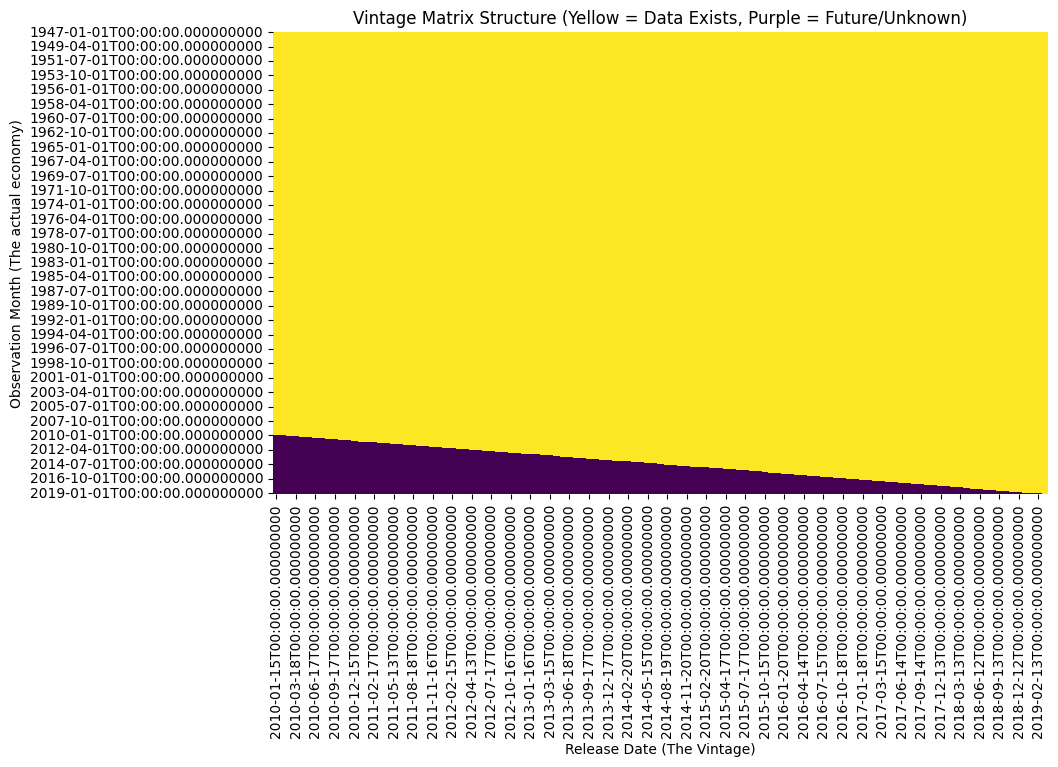


=== 3. THE REVISION HISTORY OF A SINGLE MONTH ===


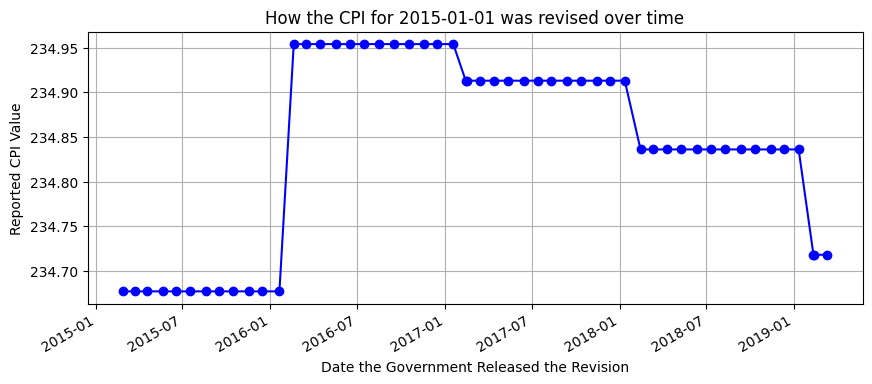

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your CPI vintage matrix
CACHE_DIR = '/content/drive/My Drive/HEC Thesis/Data/cache'
cpi_matrix = pd.read_parquet(f"{CACHE_DIR}/vintage_cpi.parquet")

print("=== 1. THE RAW GRID (Bottom Right Corner) ===")
print("Rows = The month being measured")
print("Columns = The date the government released the report")
# We display the last 15 rows and last 6 columns so it fits on your screen
display(cpi_matrix.iloc[-15:, -6:])


print("\n=== 2. THE STAIRCASE HEATMAP ===")
# This shows WHERE data exists.
# You will see a triangle of missing data (purple) because the government
# can't publish data for the future!
plt.figure(figsize=(10, 6))
# We map True (data exists) to Yellow, False (NaN) to Purple
sns.heatmap(cpi_matrix.notna(), cbar=False, cmap='viridis')
plt.title("Vintage Matrix Structure (Yellow = Data Exists, Purple = Future/Unknown)")
plt.xlabel("Release Date (The Vintage)")
plt.ylabel("Observation Month (The actual economy)")
plt.show()


print("\n=== 3. THE REVISION HISTORY OF A SINGLE MONTH ===")
# Let's pick a random month in the middle of your dataset, say January 2015,
# and see how the government revised its CPI value over the next few years.
sample_month = pd.Timestamp('2015-01-01')

if sample_month in cpi_matrix.index:
    plt.figure(figsize=(10, 4))
    # Drop NaNs to only plot the dates after it was initially published
    revisions = cpi_matrix.loc[sample_month].dropna()
    revisions.plot(marker='o', linestyle='-', color='b')

    plt.title(f"How the CPI for {sample_month.date()} was revised over time")
    plt.xlabel("Date the Government Released the Revision")
    plt.ylabel("Reported CPI Value")
    plt.grid(True)
    plt.show()
else:
    print(f"Sample month {sample_month.date()} not found in index.")

In [ ]:
import pandas as pd
import os

CACHE_DIR = '/content/drive/My Drive/HEC Thesis/Data/cache'
OUT_DIR   = '/content/drive/My Drive/HEC Thesis/Data'

VINTAGE_VARS = [
    'cpi', 'core_cpi', 'pce', 'core_pce',
    'unemployment_rate', 'nonfarm_payroll',
    'gdp', 'gdp_deflator', 'nat_unemp_rate'
]

print("=== Compressing Vintage Matrices to 1D ===")

flattened_data = {}

for var in VINTAGE_VARS:
    path = f"{CACHE_DIR}/vintage_{var}.parquet"
    if os.path.exists(path):
        # Load the 2D matrix
        matrix = pd.read_parquet(path)

        # For every column (vintage date), grab the last non-NaN value
        # This is the "most recent and up-to-date" observation known on that day
        latest_known_values = matrix.apply(lambda col: col.dropna().iloc[-1] if not col.dropna().empty else None)

        flattened_data[var] = latest_known_values
        print(f"  ✓ {var} compressed.")
    else:
        print(f"  Missing: {var}")

# Combine all the 1D series into a single DataFrame
compressed_df = pd.DataFrame(flattened_data)

# Right now, the index only has the exact days the government released reports.
# We want a continuous daily calendar so you can look up ANY date.
print("\n=== Expanding to a Daily Calendar ===")
start_date = compressed_df.index.min()
end_date = compressed_df.index.max()
daily_index = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex and forward-fill. If no report was published on a Tuesday,
# it carries forward the data from Monday.
daily_macro_df = compressed_df.reindex(daily_index).ffill()
daily_macro_df.index.name = 'date'

# Save it
out_path = os.path.join(OUT_DIR, 'latest_macro_daily.csv')
daily_macro_df.to_csv(out_path)

print(f"🚀 SUCCESS! Dataset flattened.")
print(f"Saved to: {out_path}")
print(f"Shape: {daily_macro_df.shape} (Rows = Days, Columns = Macro Variables)")

# Display the last 5 days to verify
display(daily_macro_df)

=== Compressing Vintage Matrices to 1D ===
  ✓ cpi compressed.
  ✓ core_cpi compressed.
  ✓ pce compressed.
  ✓ core_pce compressed.
  ✓ unemployment_rate compressed.
  ✓ nonfarm_payroll compressed.
  ✓ gdp compressed.
  ✓ gdp_deflator compressed.
  ✓ nat_unemp_rate compressed.

=== Expanding to a Daily Calendar ===
🚀 SUCCESS! Dataset flattened.
Saved to: /content/drive/My Drive/HEC Thesis/Data/latest_macro_daily.csv
Shape: (5822, 9) (Rows = Days, Columns = Macro Variables)


,cpi,core_cpi,pce,core_pce,unemployment_rate,nonfarm_payroll,gdp,gdp_deflator,nat_unemp_rate
date,,,,,,,,,
2010-01-15,217.541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-16,217.541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-17,217.541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-18,217.541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-19,217.541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-12-19,253.113,331.068,127.625,126.954,4.6,159552.0,30485.729,128.248,4.106349
2025-12-20,253.113,331.068,127.625,126.954,4.6,159552.0,30485.729,128.248,4.106349
2025-12-21,253.113,331.068,127.625,126.954,4.6,159552.0,30485.729,128.248,4.106349


In [6]:
import pandas as pd
import os

CACHE_DIR = '/content/drive/My Drive/HEC Thesis/Data/cache'
OUT_DIR   = '/content/drive/My Drive/HEC Thesis/Data'

print("=== 1. Stacking the FOMC Calendar Dates ===")
events = pd.melt(
    fomc_calendar,
    value_vars=['blackout_date', 'meeting_date', 'minutes_date'],
    var_name='event_type',
    value_name='date'
)

events = events.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
events = events.drop_duplicates(subset=['date']).reset_index(drop=True)

print(f"Created a vertical timeline of {len(events)} individual FOMC event dates.")

# -------------------------------------------------------------------
# 2. Merge the Flattened Vintage Macro Data to EVERY date
# -------------------------------------------------------------------
print("\n=== 2. Merging Macro Data ===")
VINTAGE_VARS = ['cpi', 'core_cpi', 'pce', 'core_pce', 'unemployment_rate', 'nonfarm_payroll', 'gdp', 'gdp_deflator', 'nat_unemp_rate']

for var in VINTAGE_VARS:
    path = f"{CACHE_DIR}/vintage_{var}.parquet"
    if os.path.exists(path):
        matrix = pd.read_parquet(path)

        # Flatten to 1D
        latest_known = matrix.apply(lambda col: col.dropna().iloc[-1] if not col.dropna().empty else None).dropna()

        macro_df = latest_known.to_frame(name=var)
        macro_df.index.name = 'release_date'
        macro_df = macro_df.sort_index()

        # ---> NEW: Calculate YoY Inflation BEFORE merging <---
        # Assuming your Parquet files store the raw index levels (e.g., CPI = 310.5)
        # and represent strictly monthly releases.
        if var in ['cpi', 'core_cpi', 'pce', 'core_pce']:
            macro_df[f'{var}_yoy'] = macro_df[var].pct_change(periods=12) * 100

        # Match each specific event date to the closest prior release date
        events = pd.merge_asof(events, macro_df, left_on='date', right_on='release_date', direction='backward')

# -------------------------------------------------------------------
# 3. Merge Market Data to EVERY date
# -------------------------------------------------------------------
print("\n=== 3. Merging Market Data ===")
MARKET_VARS = ['fed_funds_rate', 'yield_3mo', 'yield_6mo', 'yield_2yr', 'yield_5yr', 'yield_10yr', 'vix', 'breakeven_10yr', 'term_spread_10_2', 'real_rate_5yr', 'fff_implied_rate']

for var in MARKET_VARS:
    path = f"{CACHE_DIR}/market_{var}.parquet"
    if os.path.exists(path):
        market_series = pd.read_parquet(path).squeeze().dropna()
        market_df = market_series.to_frame(name=var)
        market_df.index.name = 'market_date'
        market_df = market_df.sort_index()

        # Match each specific event date to the closest prior market close
        events = pd.merge_asof(events, market_df, left_on='date', right_on='market_date', direction='backward')

# -------------------------------------------------------------------
# 4. Final Cleanup & Feature Engineering
# -------------------------------------------------------------------
final_stacked_dataset = events.set_index('date')

# ---> NEW: Calculate the Unemployment Gap <---
if 'unemployment_rate' in final_stacked_dataset.columns and 'nat_unemp_rate' in final_stacked_dataset.columns:
    final_stacked_dataset['unemployment_gap'] = final_stacked_dataset['unemployment_rate'] - final_stacked_dataset['nat_unemp_rate']

out_path = os.path.join(OUT_DIR, 'Macro_Master.csv')
final_stacked_dataset.to_csv(out_path)

print(f"\n🚀 SUCCESS! Final dataset built: {final_stacked_dataset.shape}")
print(f"Saved to: {out_path}")
display(final_stacked_dataset.head(10))

=== 1. Stacking the FOMC Calendar Dates ===
Created a vertical timeline of 360 individual FOMC event dates.

=== 2. Merging Macro Data ===

=== 3. Merging Market Data ===

🚀 SUCCESS! Final dataset built: (360, 26)
Saved to: /content/drive/My Drive/HEC Thesis/Data/Macro_Master.csv


,event_type,cpi,cpi_yoy,core_cpi,core_cpi_yoy,pce,pce_yoy,core_pce,core_pce_yoy,unemployment_rate,...,yield_6mo,yield_2yr,yield_5yr,yield_10yr,vix,breakeven_10yr,term_spread_10_2,real_rate_5yr,fff_implied_rate,unemployment_gap
date,,,,,,,,,,,,,,,,,,,,,
2011-01-08,blackout_date,219.146,0.737792,221.982,NaN,111.493,NaN,110.424,NaN,9.4,...,0.18,0.60,1.96,3.34,17.14,2.36,2.74,0.05,NaN,NaN
2011-01-26,meeting_date,220.252,1.393953,222.187,NaN,111.493,NaN,110.424,NaN,9.4,...,0.18,0.62,2.03,3.45,16.64,2.29,2.83,0.07,NaN,NaN
2011-02-16,minutes_date,220.186,1.194465,222.187,NaN,111.869,NaN,110.493,NaN,9.0,...,0.16,0.86,2.37,3.62,16.72,2.25,2.76,0.43,NaN,3.8
2011-03-04,blackout_date,221.062,1.595195,222.587,NaN,112.166,NaN,110.662,NaN,8.9,...,0.16,0.68,2.17,3.49,19.06,2.49,2.81,-0.07,NaN,3.7
2011-03-15,meeting_date,221.062,1.595195,222.587,NaN,112.166,NaN,110.662,NaN,8.9,...,0.14,0.63,2.00,3.33,24.32,2.40,2.70,-0.16,NaN,3.7
2011-04-05,minutes_date,222.270,2.085620,223.029,NaN,112.601,NaN,110.826,NaN,8.8,...,0.15,0.84,2.28,3.50,17.25,2.56,2.66,-0.04,NaN,3.6
2011-04-14,blackout_date,222.270,2.085620,223.029,NaN,112.601,NaN,110.826,NaN,8.8,...,0.13,0.77,2.23,3.51,16.27,2.62,2.74,-0.02,NaN,3.6
2011-04-27,meeting_date,223.490,2.716714,223.331,NaN,112.601,NaN,110.826,NaN,8.8,...,0.11,0.65,2.06,3.39,15.35,2.58,2.74,-0.31,NaN,3.6
2011-05-18,minutes_date,224.433,3.318694,223.745,NaN,113.081,NaN,110.996,NaN,9.0,...,0.08,0.58,1.87,3.18,16.23,2.36,2.60,-0.27,NaN,3.8


In [11]:
import requests
import pandas as pd
import os
import time

API_KEY = 'f81255531fa6b64772aaab64d80e9b65' # Replace with your actual key or load from env
CACHE_DIR = '/content/drive/My Drive/HEC Thesis/Data/cache'
os.makedirs(CACHE_DIR, exist_ok=True)

# Dictionary mapping your variable names to FRED Series IDs
INFLATION_SERIES = {
    'cpi': 'CPIAUCSL',
    'core_cpi': 'CPILFESL',
    'pce': 'PCEPI',
    'core_pce': 'PCEPILFE'
}

def fetch_vintage_matrix(series_id, units='lin'):
    """
    Hits the FRED/ALFRED API to pull all historical observations and revisions,
    then pivots them into a vintage matrix.
    """
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        'series_id': series_id,
        'api_key': API_KEY,
        'file_type': 'json',
        'units': units,
        # Starting in 2000 ensures you have plenty of runway for your 2010 timeline
        'realtime_start': '2000-01-01',
        'realtime_end': '9999-12-31'
    }

    response = requests.get(url, params=params)
    response.raise_for_status() # Flag any API errors immediately
    data = response.json()

    # Load into DataFrame
    df = pd.DataFrame(data['observations'])

    # Clean and format
    df = df[df['value'] != '.'] # Drop missing values standard to FRED
    df['date'] = pd.to_datetime(df['date'])
    df['realtime_start'] = pd.to_datetime(df['realtime_start'])
    df['value'] = df['value'].astype(float)

    # Pivot: Index = Observation Date, Columns = Release Date (Vintage)
    vintage_matrix = df.pivot_table(index='date', columns='realtime_start', values='value')

    return vintage_matrix

print("=== Fetching Vintage Inflation Data (Levels & YoY) ===")

for var_name, series_id in INFLATION_SERIES.items():
    print(f"Pulling {var_name}...")

    # 1. Pull the standard index levels (units='lin' is the default)
    level_matrix = fetch_vintage_matrix(series_id, units='lin')
    level_matrix.to_parquet(f"{CACHE_DIR}/vintage_{var_name}.parquet")

    # 2. Pull the YoY percent change (units='pc1')
    yoy_matrix = fetch_vintage_matrix(series_id, units='pc1')
    yoy_matrix.to_parquet(f"{CACHE_DIR}/vintage_{var_name}_yoy.parquet")

    # Pause briefly to respect FRED's API rate limits
    time.sleep(1)

print("✅ Vintage inflation data (Levels + YoY) successfully cached!")

=== Fetching Vintage Inflation Data (Levels & YoY) ===
Pulling cpi...


HTTPError: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=f81255531fa6b64772aaab64d80e9b65&file_type=json&units=pc1&realtime_start=2000-01-01&realtime_end=9999-12-31